In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [9]:
#series
values=[10,20,30,40,50]
s=pd.Series(values,index=['a','b','c','d','e']) #dups allowed in index


#dataframe
data = {
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'age': [25, 30, 35, 40, 45],
    'city': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix']
}
df = pd.DataFrame(data)
df=df.set_index('name') #set index to name column

In [11]:
df.loc['Alice'] #access row by index label

age           25
city    New York
Name: Alice, dtype: object

In [14]:
df1=pd.DataFrame({
    'a': [1, 2, 3]
},index=[0,1,2])
df2=pd.DataFrame({
    'a':[10,20,30]
},index=[1,2,0])

In [15]:
df1+df2

,a
0,31
1,12
2,23


In [16]:
df=df.reset_index() #reset index to default integer index

In [23]:
df.to_csv('data.csv',index=None) #save to csv

In [24]:
pd.read_csv('data.csv') #read from csv

,name,age,city
0,Alice,25,New York
1,Bob,30,Los Angeles
2,Charlie,35,Chicago
3,David,40,Houston
4,Eva,45,Phoenix


In [25]:
from sklearn.datasets import fetch_california_housing

In [27]:
data = fetch_california_housing(as_frame=True).frame

In [ ]:
data.sample() #get random sample of data
data.head() #view first few rows (if number specified that many rows got)
data.tail() #view last few rows (if number specified that many rows got)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
15638,2.9871,52.0,3.724638,1.046584,2062.0,2.134576,37.79,-122.41,3.8


In [33]:
data.columns #get columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [37]:
pd.options.display.max_columns = 500 #show only 5 columns in output
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [38]:
data.describe() #get summary statistics

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

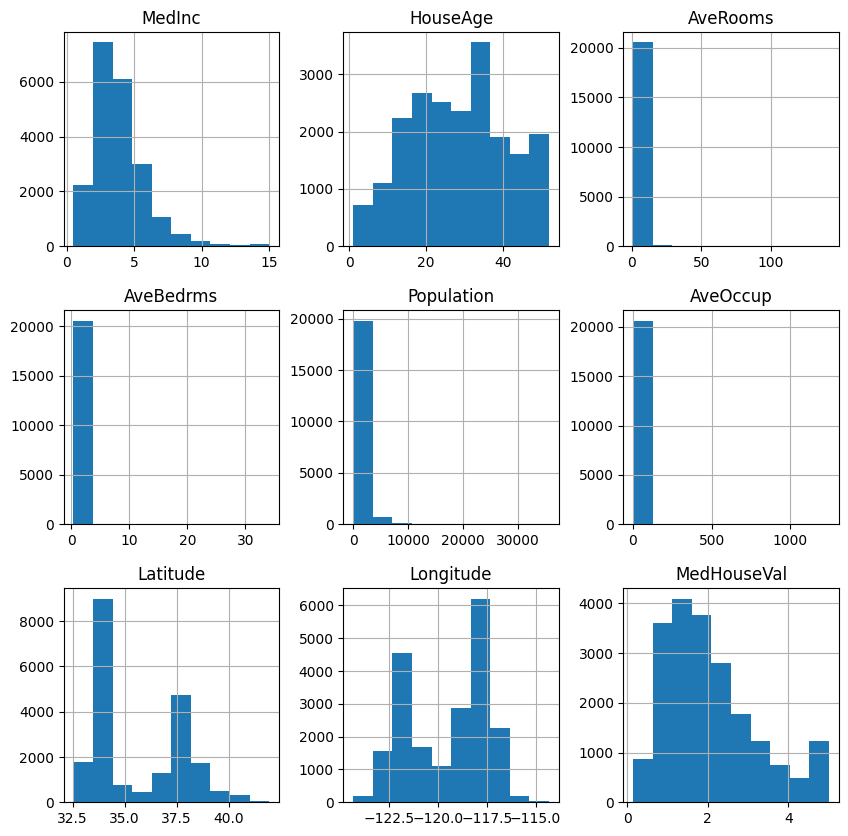

In [43]:
data.HouseAge #or data['HouseAge'] #access column by name
#then can add .mean(), .sum(), etc. to perform operations on the column
#data['HouseAge'].hist() #uses matplotlib
#also can do for full datagram
data.hist(figsize=(10,10)) #histogram for all numeric columns

In [ ]:
df
df.loc['Eva','age']
df.iloc[4,0] #to use number based indexing if index is string

np.int64(45)

In [ ]:
df.at['Eva','age'] #to get only a single value doesnt work for full row
df.iat[4,0] #to get only a single value using number based indexing

#same thing to make changes to values , add new rows also
df.loc["John"]=[30,"mumbai"]
df
#normal slicing also works

,age,city
name,,
Alice,25,New York
Bob,30,Los Angeles
Charlie,35,Chicago
David,40,Houston
Eva,45,Phoenix
John,30,mumbai


In [61]:
#to apply custom functions to row
def myfunc(x):
    if x%3==0:
        return x**2
    else:
        return x//2

In [ ]:
df.age.apply(myfunc) #apply function to column
#doesnt apply to dataframe...need to store it with df.age=... to store changes

name
Alice        12
Bob         900
Charlie      17
David        20
Eva        2025
John        900
Name: age, dtype: int64

In [69]:
df['summary'] = df.apply(lambda x: f"Age: {x['age']}, City: {x['city']}", axis=1)

In [ ]:
df
#drop to drop columns
df.drop('summary', axis=1)

In [79]:
df.at['Alice','age']=float('nan') #set value to NaN
df.dropna() #drop rows with NaN values
df.fillna(0) #fill NaN values with 0
df.age.fillna(df.age.mean()) #fill NaN values with mean of column

name
Alice      36.0
Bob        30.0
Charlie    35.0
David      40.0
Eva        45.0
John       30.0
Name: age, dtype: float64

In [83]:
df.at['Bob','city'] = None #set value for city
df.info()
df[df.age.notna()]

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, Alice to John
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     5 non-null      float64
 1   city    5 non-null      object 
dtypes: float64(1), object(1)
memory usage: 316.0+ bytes


,age,city
name,,
Bob,30.0,None
Charlie,35.0,Chicago
David,40.0,Houston
Eva,45.0,Phoenix
John,30.0,mumbai


In [85]:
for i,row in df.iterrows():
    print(f"Index: {i}, Row: {row['age']}, {row['city']}") #iterates over rows
for i,col in df.items():
    print(f"Column: {col.name}, Values: {col.values}") #iterates over columns

Index: Alice, Row: nan, New York
Index: Bob, Row: 30.0, None
Index: Charlie, Row: 35.0, Chicago
Index: David, Row: 40.0, Houston
Index: Eva, Row: 45.0, Phoenix
Index: John, Row: 30.0, mumbai
Column: age, Values: [nan 30. 35. 40. 45. 30.]
Column: city, Values: ['New York' None 'Chicago' 'Houston' 'Phoenix' 'mumbai']


In [90]:
#not operator is ~ in pandas
#some filtering examples (kinda common with numpy)
print(df[~df.age.notna()])#filter out rows where age is NaN
print(df[df.city == 'New York']) #filter rows where city is New York
df=df.reset_index()
df[df.name.str.endswith('e')]

    name  age      city
0  Alice  NaN  New York
    name  age      city
0  Alice  NaN  New York


,index,name,age,city
0,0,Alice,NaN,New York
2,2,Charlie,35.0,Chicago


In [93]:
import datetime as dt
df['age']=df['age'].fillna(30)
df['dob']=df['age'].apply(lambda x: dt.datetime.now() - dt.timedelta(days=x*365))
df

,index,name,age,city,dob
0,0,Alice,30.0,New York,1995-08-21 18:55:01.088956
1,1,Bob,30.0,None,1995-08-21 18:55:01.088986
2,2,Charlie,35.0,Chicago,1990-08-22 18:55:01.089005
3,3,David,40.0,Houston,1985-08-23 18:55:01.089007
4,4,Eva,45.0,Phoenix,1980-08-24 18:55:01.089008
5,5,John,30.0,mumbai,1995-08-21 18:55:01.089010


In [94]:
ages=[35,45]
df[df.age.isin(ages)] #filter rows where age is in ages list

,index,name,age,city,dob
2,2,Charlie,35.0,Chicago,1990-08-22 18:55:01.089005
4,4,Eva,45.0,Phoenix,1980-08-24 18:55:01.089008


In [108]:
#query method
df.query('age>30') #faster as it uses numexpr
df=df.reset_index(drop=True)
df=df.drop('index',axis=1)

In [111]:
#grouping 
df['city']=df['city'].fillna('LA')
df.loc[6]=['John', 40, 'LA', None]  # NaT for missing datetime values
df.groupby('city').agg({
    'age': ['mean','min','max','sum'] #group by city and get mean of numeric columns
})

age                  
          mean   min   max   sum
city                            
Chicago   35.0  35.0  35.0  35.0
Houston   40.0  40.0  40.0  40.0
LA        35.0  30.0  40.0  70.0
New York  30.0  30.0  30.0  30.0
Phoenix   45.0  45.0  45.0  45.0
mumbai    30.0  30.0  30.0  30.0

In [113]:
df.sort_values('age')

,name,age,city,dob
0,Alice,30.0,New York,1995-08-21 18:55:01.088956
1,Bob,30.0,LA,1995-08-21 18:55:01.088986
5,John,30.0,mumbai,1995-08-21 18:55:01.089010
2,Charlie,35.0,Chicago,1990-08-22 18:55:01.089005
3,David,40.0,Houston,1985-08-23 18:55:01.089007
6,John,40.0,LA,NaT
4,Eva,45.0,Phoenix,1980-08-24 18:55:01.089008


In [114]:
df1=pd.DataFrame({
    'Item':['A','B','C'],
    'Price':[10,20,30]
})

df2=pd.DataFrame({
    'Item':['D','E','F'],
    'Price':[40,50,60]
})

In [116]:
pd.concat([df1,df2]).reset_index(drop=True) #concatenate dataframes and reset index

,Item,Price
0,A,10
1,B,20
2,C,30
3,D,40
4,E,50
5,F,60


In [117]:
df1=pd.DataFrame({
    'Item':['A','B','C'],
    'Price':[10,20,30]
})
df2=pd.DataFrame({
    'Country':['D','E','F'],
    'Available':[True,False,True]
})

In [118]:
pd.concat([df1,df2], axis=1)

,Item,Price,Country,Available
0,A,10,D,True
1,B,20,E,False
2,C,30,F,True


In [120]:
df3=pd.DataFrame({
    'Item':['B','C','D'],
    'Country':['D','E','F']
})

In [127]:
print(pd.merge(df1,df3,how='inner')) #inner is default
print(pd.merge(df1,df3,how='outer')) #outer join
print(pd.merge(df1,df3,how='left')) #left join
print(pd.merge(df1,df3,how='right',on='Item')) #right join

  Item  Price Country
0    B     20       D
1    C     30       E
  Item  Price Country
0    A   10.0     NaN
1    B   20.0       D
2    C   30.0       E
3    D    NaN       F
  Item  Price Country
0    A     10     NaN
1    B     20       D
2    C     30       E
  Item  Price Country
0    B   20.0       D
1    C   30.0       E
2    D    NaN       F
